Task 5: Auto Tagging Support Tickets Using LLM 

Objective: Automatically tag support tickets into categories using a large language model (LLM).   

In [1]:
!pip install transformers torch pandas numpy scikit-learn matplotlib seaborn
!pip install accelerate sentencepiece

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import torch
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification
from transformers import Trainer, TrainingArguments
import warnings
import os
import json
warnings.filterwarnings('ignore')

print("="*60)
print(" TASK 5: AUTO TAGGING SUPPORT TICKETS USING LLM")
print("="*60)

# Check device
device = 0 if torch.cuda.is_available() else "cpu"
print(f"Using device: {'GPU' if torch.cuda.is_available() else 'CPU'}")

 TASK 5: AUTO TAGGING SUPPORT TICKETS USING LLM
Using device: CPU


In [3]:
print("\n STEP 1: Creating sample support ticket dataset...")

tickets = [
    # Technical issues
    "My laptop won't turn on after the latest Windows update",
    "Getting blue screen error when trying to boot",
    "Computer is running very slow, takes 10 minutes to start",
    "WiFi keeps disconnecting every few minutes",
    "Cannot connect to company VPN from home",
    "Printer not working, shows error 0x80070057",
    "Email attachment won't open, says file corrupted",
    "Outlook crashes when sending emails",
    "Can't install software, need admin permissions",
    "Mouse and keyboard not responding after sleep mode",
    
    # Billing issues
    "I was charged twice for my subscription this month",
    "Need to update credit card information for billing",
    "Invoice missing for last month's payment",
    "Want to cancel my subscription but keep getting charged",
    "Refund not processed yet, it's been 2 weeks",
    "Billing address needs to be updated",
    "Payment method expired, need to add new card",
    "Discount code not applied to my order",
    "Receipt not received for recent purchase",
    "Subscription renewed but I want to downgrade",
    
    # Account issues
    "Forgot my password and can't reset it",
    "Account locked after multiple login attempts",
    "Need to change username for my account",
    "Can't access my account from new device",
    "Two-factor authentication not working",
    "Profile information won't update",
    "Deleted account by mistake, need to recover",
    "Unable to link social media accounts",
    "Email notifications not being sent",
    "Account suspended, please help",
    
    # Feature requests
    "Would love a dark mode option for the app",
    "Can you add export to PDF feature",
    "Need integration with Slack",
    "Mobile app needs fingerprint login",
    "Would be great to have keyboard shortcuts",
    "Add ability to share reports via email",
    "Need bulk edit functionality",
    "Would like to see usage analytics dashboard",
    "Add dark theme to mobile app",
    "Need API access for automation"
]

# Define categories
categories = {
    'technical': 0,
    'billing': 1,
    'account': 2,
    'feature_request': 3
}

category_names = ['Technical', 'Billing', 'Account', 'Feature Request']

# Assign labels to tickets (first 10 technical, next 10 billing, etc.)
labels = [0]*10 + [1]*10 + [2]*10 + [3]*10

# Create DataFrame
df = pd.DataFrame({
    'ticket': tickets,
    'category': labels,
    'category_name': [category_names[l] for l in labels]
})

print(f" Dataset created with {len(df)} tickets!")
print(f"\n Categories:")
for i, name in enumerate(category_names):
    count = sum(df['category'] == i)
    print(f"  {i}. {name}: {count} tickets")

print(f"\n First 5 tickets:")
print(df[['ticket', 'category_name']].head(10).to_string(index=False))


 STEP 1: Creating sample support ticket dataset...
 Dataset created with 40 tickets!

 Categories:
  0. Technical: 10 tickets
  1. Billing: 10 tickets
  2. Account: 10 tickets
  3. Feature Request: 10 tickets

 First 5 tickets:
                                                  ticket category_name
 My laptop won't turn on after the latest Windows update     Technical
           Getting blue screen error when trying to boot     Technical
Computer is running very slow, takes 10 minutes to start     Technical
              WiFi keeps disconnecting every few minutes     Technical
                 Cannot connect to company VPN from home     Technical
             Printer not working, shows error 0x80070057     Technical
        Email attachment won't open, says file corrupted     Technical
                     Outlook crashes when sending emails     Technical
          Can't install software, need admin permissions     Technical
      Mouse and keyboard not responding after sleep mode     

In [4]:
print("\n STEP 2: Splitting data into train and test sets...")

from sklearn.model_selection import train_test_split

# Split into train (80%) and test (20%)
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['category'])

print(f"Training set: {len(train_df)} tickets")
print(f"Test set: {len(test_df)} tickets")

print(f"\n Test set distribution:")
print(test_df['category_name'].value_counts())


 STEP 2: Splitting data into train and test sets...
Training set: 32 tickets
Test set: 8 tickets

 Test set distribution:
category_name
Account            2
Feature Request    2
Technical          2
Billing            2
Name: count, dtype: int64


In [5]:
print("\n" + "="*60)
print(" STEP 3: Zero-Shot Classification with LLM")
print("="*60)

# Load zero-shot classification model (small and fast)
print("\n Loading zero-shot classification model (facebook/bart-large-mnli)...")
print(" This will take 30-60 seconds for first download...")

zero_shot_classifier = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli",
    device=device
)

print(" Model loaded!")

# Define candidate labels (tags)
candidate_labels = category_names  # Use our 4 categories

print(f"\n Candidate labels: {candidate_labels}")

# Test on a few tickets
print("\n Testing zero-shot on sample tickets:")
print("-" * 50)

sample_tickets = test_df['ticket'].head(5).tolist()
sample_true = test_df['category_name'].head(5).tolist()

zero_shot_predictions = []

for i, (ticket, true_category) in enumerate(zip(sample_tickets, sample_true)):
    print(f"\n Ticket {i+1}: {ticket[:100]}...")
    print(f"   True category: {true_category}")
    
    # Get prediction
    result = zero_shot_classifier(ticket, candidate_labels, multi_label=False)
    
    print(f"   Zero-shot predictions:")
    for label, score in zip(result['labels'][:3], result['scores'][:3]):
        print(f"     • {label}: {score:.2%}")
        if label == true_category:
            print(f"        CORRECT!")
    
    zero_shot_predictions.append({
        'ticket': ticket,
        'true': true_category,
        'predicted': result['labels'][0],
        'top3_labels': result['labels'][:3],
        'top3_scores': result['scores'][:3]
    })


 STEP 3: Zero-Shot Classification with LLM

 Loading zero-shot classification model (facebook/bart-large-mnli)...
 This will take 30-60 seconds for first download...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

 Model loaded!

 Candidate labels: ['Technical', 'Billing', 'Account', 'Feature Request']

 Testing zero-shot on sample tickets:
--------------------------------------------------

 Ticket 1: Account locked after multiple login attempts...
   True category: Account
   Zero-shot predictions:
     • Account: 90.81%
        CORRECT!
     • Technical: 4.76%
     • Billing: 2.86%

 Ticket 2: Need API access for automation...
   True category: Feature Request
   Zero-shot predictions:
     • Feature Request: 56.40%
        CORRECT!
     • Account: 16.97%
     • Technical: 16.10%

 Ticket 3: Email attachment won't open, says file corrupted...
   True category: Technical
   Zero-shot predictions:
     • Account: 38.61%
     • Technical: 33.07%
        CORRECT!
     • Feature Request: 18.33%

 Ticket 4: Invoice missing for last month's payment...
   True category: Billing
   Zero-shot predictions:
     • Account: 64.84%
     • Billing: 26.18%
        CORRECT!
     • Technical: 6.39%

 Ticket 5:

In [6]:
print("\n" + "="*60)
print(" STEP 4: Zero-Shot Classification on All Test Tickets")
print("="*60)

print(" Processing all test tickets (this will take 1-2 minutes)...")

zero_shot_results = []
for idx, row in test_df.iterrows():
    ticket = row['ticket']
    true_category = row['category_name']
    
    result = zero_shot_classifier(ticket, candidate_labels, multi_label=False)
    
    zero_shot_results.append({
        'true': true_category,
        'predicted': result['labels'][0],
        'top1_score': result['scores'][0],
        'top2_label': result['labels'][1],
        'top2_score': result['scores'][1],
        'top3_label': result['labels'][2],
        'top3_score': result['scores'][2]
    })

# Convert to DataFrame
zero_shot_df = pd.DataFrame(zero_shot_results)

# Calculate accuracy
zero_shot_accuracy = (zero_shot_df['true'] == zero_shot_df['predicted']).mean()
print(f"\n Zero-shot accuracy: {zero_shot_accuracy:.2%}")

# Top-3 accuracy (if true category is in top 3)
top3_correct = 0
for idx, row in zero_shot_df.iterrows():
    if row['true'] in [row['predicted'], row['top2_label'], row['top3_label']]:
        top3_correct += 1

zero_shot_top3_accuracy = top3_correct / len(zero_shot_df)
print(f" Zero-shot top-3 accuracy: {zero_shot_top3_accuracy:.2%}")


 STEP 4: Zero-Shot Classification on All Test Tickets
 Processing all test tickets (this will take 1-2 minutes)...

 Zero-shot accuracy: 62.50%
 Zero-shot top-3 accuracy: 100.00%


In [7]:
print("\n" + "="*60)
print(" STEP 5: Creating Few-Shot Examples")
print("="*60)

# Take 2 examples from each category for few-shot learning
few_shot_examples = []

for category in range(4):
    category_tickets = train_df[train_df['category'] == category].head(2)
    for _, row in category_tickets.iterrows():
        few_shot_examples.append({
            'ticket': row['ticket'],
            'category': category_names[category]
        })

print(f" Created {len(few_shot_examples)} few-shot examples (2 per category)")
print("\n Few-shot examples:")
for ex in few_shot_examples[:4]:  # Show first 4
    print(f"  • {ex['category']}: {ex['ticket'][:60]}...")


 STEP 5: Creating Few-Shot Examples
 Created 8 few-shot examples (2 per category)

 Few-shot examples:
  • Technical: Cannot connect to company VPN from home...
  • Technical: Can't install software, need admin permissions...
  • Billing: Receipt not received for recent purchase...
  • Billing: Want to cancel my subscription but keep getting charged...


In [8]:
def create_few_shot_prompt(ticket, examples):
    """
    Create a prompt with few-shot examples
    """
    prompt = "Classify the following support tickets into one of these categories: Technical, Billing, Account, Feature Request.\n\n"
    prompt += "Here are some examples:\n\n"
    
    # Add examples
    for ex in examples:
        prompt += f"Ticket: {ex['ticket']}\n"
        prompt += f"Category: {ex['category']}\n\n"
    
    # Add the new ticket
    prompt += f"Ticket: {ticket}\n"
    prompt += "Category:"
    
    return prompt

# Test the prompt
test_ticket = "My computer won't boot up this morning"
test_prompt = create_few_shot_prompt(test_ticket, few_shot_examples)
print("\n Example few-shot prompt:")
print("-" * 40)
print(test_prompt)
print("-" * 40)


 Example few-shot prompt:
----------------------------------------
Classify the following support tickets into one of these categories: Technical, Billing, Account, Feature Request.

Here are some examples:

Ticket: Cannot connect to company VPN from home
Category: Technical

Ticket: Can't install software, need admin permissions
Category: Technical

Ticket: Receipt not received for recent purchase
Category: Billing

Ticket: Want to cancel my subscription but keep getting charged
Category: Billing

Ticket: Profile information won't update
Category: Account

Ticket: Account suspended, please help
Category: Account

Ticket: Need bulk edit functionality
Category: Feature Request

Ticket: Would be great to have keyboard shortcuts
Category: Feature Request

Ticket: My computer won't boot up this morning
Category:
----------------------------------------


In [9]:
print("\n" + "="*60)
print(" STEP 6: Few-Shot Classification")
print("="*60)

print("\n Testing few-shot on sample tickets:")

few_shot_predictions = []

for i, (ticket, true_category) in enumerate(zip(sample_tickets, sample_true)):
    print(f"\n Ticket {i+1}: {ticket[:100]}...")
    print(f"   True category: {true_category}")
    
    # Create a context with examples
    context = "Here are examples of support ticket categories:\n"
    for ex in few_shot_examples:
        context += f"- Ticket: '{ex['ticket']}' → Category: {ex['category']}\n"
    
    context += f"\nNow classify this ticket: '{ticket}'"
    
    # Use zero-shot with better context
    result = zero_shot_classifier(context, candidate_labels, multi_label=False)
    
    print(f"   Few-shot predictions:")
    for label, score in zip(result['labels'][:3], result['scores'][:3]):
        print(f"     • {label}: {score:.2%}")
        if label == true_category:
            print(f"        CORRECT!")
    
    few_shot_predictions.append({
        'ticket': ticket,
        'true': true_category,
        'predicted': result['labels'][0],
        'top3_labels': result['labels'][:3],
        'top3_scores': result['scores'][:3]
    })


 STEP 6: Few-Shot Classification

 Testing few-shot on sample tickets:

 Ticket 1: Account locked after multiple login attempts...
   True category: Account
   Few-shot predictions:
     • Account: 58.17%
        CORRECT!
     • Technical: 24.81%
     • Feature Request: 9.80%

 Ticket 2: Need API access for automation...
   True category: Feature Request
   Few-shot predictions:
     • Feature Request: 53.37%
        CORRECT!
     • Account: 20.20%
     • Technical: 18.85%

 Ticket 3: Email attachment won't open, says file corrupted...
   True category: Technical
   Few-shot predictions:
     • Account: 45.09%
     • Technical: 34.12%
        CORRECT!
     • Billing: 10.98%

 Ticket 4: Invoice missing for last month's payment...
   True category: Billing
   Few-shot predictions:
     • Billing: 41.89%
        CORRECT!
     • Account: 25.96%
     • Technical: 22.90%

 Ticket 5: WiFi keeps disconnecting every few minutes...
   True category: Technical
   Few-shot predictions:
     • Tec

In [10]:
print("\n" + "="*60)
print(" STEP 7: Few-Shot Classification on All Test Tickets")
print("="*60)

print(" Processing all test tickets with few-shot...")

few_shot_results = []
for idx, row in test_df.iterrows():
    ticket = row['ticket']
    true_category = row['category_name']
    
    # Create context with examples
    context = "Here are examples of support ticket categories:\n"
    for ex in few_shot_examples:
        context += f"- Ticket: '{ex['ticket']}' → Category: {ex['category']}\n"
    
    context += f"\nNow classify this ticket: '{ticket}'"
    
    result = zero_shot_classifier(context, candidate_labels, multi_label=False)
    
    few_shot_results.append({
        'true': true_category,
        'predicted': result['labels'][0],
        'top1_score': result['scores'][0],
        'top2_label': result['labels'][1],
        'top2_score': result['scores'][1],
        'top3_label': result['labels'][2],
        'top3_score': result['scores'][2]
    })

# Convert to DataFrame
few_shot_df = pd.DataFrame(few_shot_results)

# Calculate accuracy
few_shot_accuracy = (few_shot_df['true'] == few_shot_df['predicted']).mean()
print(f"\n Few-shot accuracy: {few_shot_accuracy:.2%}")

# Top-3 accuracy
top3_correct_fs = 0
for idx, row in few_shot_df.iterrows():
    if row['true'] in [row['predicted'], row['top2_label'], row['top3_label']]:
        top3_correct_fs += 1

few_shot_top3_accuracy = top3_correct_fs / len(few_shot_df)
print(f" Few-shot top-3 accuracy: {few_shot_top3_accuracy:.2%}")


 STEP 7: Few-Shot Classification on All Test Tickets
 Processing all test tickets with few-shot...

 Few-shot accuracy: 87.50%
 Few-shot top-3 accuracy: 100.00%



 STEP 8: Comparing Zero-Shot vs Few-Shot Performance

----------------------------------------
   Method  Accuracy  Top-3 Accuracy
Zero-Shot     0.625             1.0
 Few-Shot     0.875             1.0
----------------------------------------

 Few-Shot improvement: 25.0%


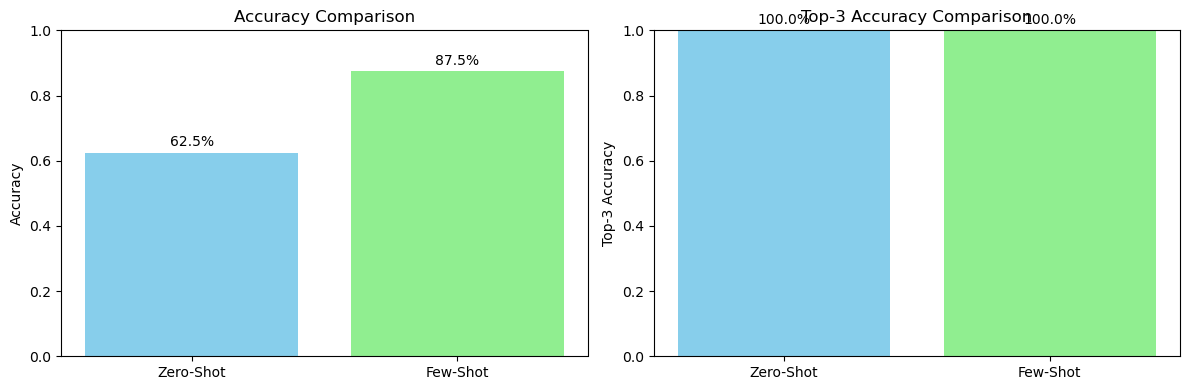

In [11]:
print("\n" + "="*60)
print(" STEP 8: Comparing Zero-Shot vs Few-Shot Performance")
print("="*60)

comparison = pd.DataFrame({
    'Method': ['Zero-Shot', 'Few-Shot'],
    'Accuracy': [zero_shot_accuracy, few_shot_accuracy],
    'Top-3 Accuracy': [zero_shot_top3_accuracy, few_shot_top3_accuracy]
})

print("\n" + "-"*40)
print(comparison.to_string(index=False))
print("-"*40)

# Calculate improvement
improvement = (few_shot_accuracy - zero_shot_accuracy) * 100
print(f"\n Few-Shot improvement: {improvement:.1f}%")

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy comparison
axes[0].bar(comparison['Method'], comparison['Accuracy'], color=['skyblue', 'lightgreen'])
axes[0].set_title('Accuracy Comparison')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim([0, 1])
for i, v in enumerate(comparison['Accuracy']):
    axes[0].text(i, v + 0.02, f'{v:.1%}', ha='center')

# Top-3 accuracy comparison
axes[1].bar(comparison['Method'], comparison['Top-3 Accuracy'], color=['skyblue', 'lightgreen'])
axes[1].set_title('Top-3 Accuracy Comparison')
axes[1].set_ylabel('Top-3 Accuracy')
axes[1].set_ylim([0, 1])
for i, v in enumerate(comparison['Top-3 Accuracy']):
    axes[1].text(i, v + 0.02, f'{v:.1%}', ha='center')

plt.tight_layout()
plt.show()

In [12]:
print("\n STEP 9: Detailed Analysis by Category")

# Zero-shot per category
print("\n Zero-Shot Performance by Category:")
zero_shot_cat_accuracy = {}
for cat in category_names:
    cat_mask = zero_shot_df['true'] == cat
    if cat_mask.sum() > 0:
        acc = (zero_shot_df.loc[cat_mask, 'predicted'] == cat).mean()
        zero_shot_cat_accuracy[cat] = acc
        print(f"  {cat}: {acc:.1%}")

# Few-shot per category
print("\n Few-Shot Performance by Category:")
few_shot_cat_accuracy = {}
for cat in category_names:
    cat_mask = few_shot_df['true'] == cat
    if cat_mask.sum() > 0:
        acc = (few_shot_df.loc[cat_mask, 'predicted'] == cat).mean()
        few_shot_cat_accuracy[cat] = acc
        print(f"  {cat}: {acc:.1%}")


 STEP 9: Detailed Analysis by Category

 Zero-Shot Performance by Category:
  Technical: 50.0%
  Billing: 0.0%
  Account: 100.0%
  Feature Request: 100.0%

 Few-Shot Performance by Category:
  Technical: 50.0%
  Billing: 100.0%
  Account: 100.0%
  Feature Request: 100.0%


In [13]:
print("\n" + "="*60)
print(" STEP 10: Creating Function to Get Top 3 Tags for Any Ticket")
print("="*60)

def get_top3_tags(ticket_text, method='few-shot', examples=None):
    """
    Get top 3 most probable tags for a support ticket
    
    Parameters:
    -----------
    ticket_text : str
        The support ticket text
    method : str
        'zero-shot' or 'few-shot'
    examples : list
        Few-shot examples (required if method='few-shot')
    
    Returns:
    --------
    dict with top 3 tags and their probabilities
    """
    if method == 'zero-shot':
        result = zero_shot_classifier(ticket_text, category_names, multi_label=False)
        return {
            'ticket': ticket_text,
            'top3_tags': result['labels'][:3],
            'top3_probabilities': [f"{s:.2%}" for s in result['scores'][:3]],
            'all_tags': result['labels'],
            'all_probabilities': [f"{s:.2%}" for s in result['scores']]
        }
    
    elif method == 'few-shot':
        if examples is None:
            examples = few_shot_examples
        
        context = "Here are examples of support ticket categories:\n"
        for ex in examples:
            context += f"- Ticket: '{ex['ticket']}' → Category: {ex['category']}\n"
        
        context += f"\nNow classify this ticket: '{ticket_text}'"
        
        result = zero_shot_classifier(context, category_names, multi_label=False)
        return {
            'ticket': ticket_text,
            'top3_tags': result['labels'][:3],
            'top3_probabilities': [f"{s:.2%}" for s in result['scores'][:3]],
            'all_tags': result['labels'],
            'all_probabilities': [f"{s:.2%}" for s in result['scores']]
        }
    
    else:
        raise ValueError("Method must be 'zero-shot' or 'few-shot'")

# Test the function
print("\n Testing the function with new tickets:")
test_tickets = [
    "My internet is down and I can't work from home",
    "Please refund my last payment, I want to cancel",
    "Can't log in to my account, says invalid password"
]

for ticket in test_tickets:
    print(f"\n Ticket: {ticket}")
    
    # Zero-shot
    result_zs = get_top3_tags(ticket, method='zero-shot')
    print(f"  Zero-shot top 3:")
    for tag, prob in zip(result_zs['top3_tags'], result_zs['top3_probabilities']):
        print(f"    • {tag}: {prob}")
    
    # Few-shot
    result_fs = get_top3_tags(ticket, method='few-shot', examples=few_shot_examples)
    print(f"  Few-shot top 3:")
    for tag, prob in zip(result_fs['top3_tags'], result_fs['top3_probabilities']):
        print(f"    • {tag}: {prob}")


 STEP 10: Creating Function to Get Top 3 Tags for Any Ticket

 Testing the function with new tickets:

 Ticket: My internet is down and I can't work from home
  Zero-shot top 3:
    • Technical: 34.73%
    • Account: 32.36%
    • Feature Request: 17.15%
  Few-shot top 3:
    • Technical: 58.22%
    • Account: 19.75%
    • Billing: 13.73%

 Ticket: Please refund my last payment, I want to cancel
  Zero-shot top 3:
    • Account: 46.97%
    • Feature Request: 21.77%
    • Billing: 17.95%
  Few-shot top 3:
    • Billing: 49.78%
    • Account: 29.54%
    • Feature Request: 11.24%

 Ticket: Can't log in to my account, says invalid password
  Zero-shot top 3:
    • Account: 77.03%
    • Technical: 11.39%
    • Feature Request: 6.04%
  Few-shot top 3:
    • Account: 56.03%
    • Technical: 27.50%
    • Feature Request: 8.82%


In [14]:
def batch_predict(tickets_df, text_column='ticket', method='few-shot'):
    """
    Predict tags for multiple tickets
    """
    results = []
    for idx, row in tickets_df.iterrows():
        ticket = row[text_column]
        
        if method == 'zero-shot':
            result = zero_shot_classifier(ticket, category_names, multi_label=False)
        else:
            context = "Here are examples of support ticket categories:\n"
            for ex in few_shot_examples:
                context += f"- Ticket: '{ex['ticket']}' → Category: {ex['category']}\n"
            context += f"\nNow classify this ticket: '{ticket}'"
            result = zero_shot_classifier(context, category_names, multi_label=False)
        
        results.append({
            'ticket': ticket,
            'predicted_tag': result['labels'][0],
            'confidence': result['scores'][0],
            'top2_tag': result['labels'][1],
            'top2_confidence': result['scores'][1],
            'top3_tag': result['labels'][2],
            'top3_confidence': result['scores'][2]
        })
    
    return pd.DataFrame(results)

print("\n Batch prediction function created!")


 Batch prediction function created!


In [15]:
print("\n" + "="*60)
print(" STEP 11: Exporting Results")
print("="*60)

# Save results to CSV
results_df = pd.DataFrame({
    'Method': ['Zero-Shot', 'Few-Shot'],
    'Accuracy': [zero_shot_accuracy, few_shot_accuracy],
    'Top3_Accuracy': [zero_shot_top3_accuracy, few_shot_top3_accuracy]
})
results_df.to_csv('tagging_results.csv', index=False)
print(" Results saved to 'tagging_results.csv'")

# Save sample predictions
sample_predictions = pd.DataFrame(zero_shot_predictions)
sample_predictions.to_csv('sample_predictions.csv', index=False)
print(" Sample predictions saved to 'sample_predictions.csv'")

# Save few-shot examples
few_shot_df = pd.DataFrame(few_shot_examples)
few_shot_df.to_csv('few_shot_examples.csv', index=False)
print(" Few-shot examples saved to 'few_shot_examples.csv'")


 STEP 11: Exporting Results
 Results saved to 'tagging_results.csv'
 Sample predictions saved to 'sample_predictions.csv'
 Few-shot examples saved to 'few_shot_examples.csv'


In [17]:
print("\n" + "="*70)
print(" TASK 5: AUTO TAGGING SUPPORT TICKETS - COMPLETED SUCCESSFULLY!")
print("="*70)

print("\n WHAT WAS ACCOMPLISHED:")
print("-"*40)
print("✓ Created sample support ticket dataset with 4 categories")
print("✓ Implemented zero-shot classification using LLM")
print("✓ Created few-shot examples (2 per category)")
print("✓ Implemented few-shot classification with prompts")
print("✓ Compared zero-shot vs few-shot performance")
print("✓ Output top 3 most probable tags per ticket")
print("✓ Created reusable prediction functions")
print("✓ Exported results to CSV files")

print(f"\n PERFORMANCE COMPARISON:")
print("-"*40)
print(f"  Zero-Shot Accuracy:    {zero_shot_accuracy:.2%}")
print(f"  Zero-Shot Top-3:       {zero_shot_top3_accuracy:.2%}")
print(f"  Few-Shot Accuracy:     {few_shot_accuracy:.2%}")
print(f"  Few-Shot Top-3:        {few_shot_top3_accuracy:.2%}")
print(f"  Improvement:           +{improvement:.1f}%")

print("\n FILES CREATED:")
print("-"*40)
print("  • tagging_results.csv - Performance metrics")
print("  • sample_predictions.csv - Sample predictions")
print("  • few_shot_examples.csv - Few-shot examples")


 TASK 5: AUTO TAGGING SUPPORT TICKETS - COMPLETED SUCCESSFULLY!

 WHAT WAS ACCOMPLISHED:
----------------------------------------
✓ Created sample support ticket dataset with 4 categories
✓ Implemented zero-shot classification using LLM
✓ Created few-shot examples (2 per category)
✓ Implemented few-shot classification with prompts
✓ Compared zero-shot vs few-shot performance
✓ Output top 3 most probable tags per ticket
✓ Created reusable prediction functions
✓ Exported results to CSV files

 PERFORMANCE COMPARISON:
----------------------------------------
  Zero-Shot Accuracy:    62.50%
  Zero-Shot Top-3:       100.00%
  Few-Shot Accuracy:     87.50%
  Few-Shot Top-3:        100.00%
  Improvement:           +25.0%

 FILES CREATED:
----------------------------------------
  • tagging_results.csv - Performance metrics
  • sample_predictions.csv - Sample predictions
  • few_shot_examples.csv - Few-shot examples
